# Lab 9. Exploratory data analysis - exercises

All of the exercises are based on lecture (https://github.com/agazbrzezny/DAT-SWPS-2026/blob/main/statistics.ipynb) and examples presented there.

In [ ]:
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

## Task 1

Use the Heart Disease dataset.

In [3]:
# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

df_heart = pd.concat([X, y], axis=1)

In [4]:
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


**Task 1.1**

Check the data card to see which features are numerical and which are categorical. Change categorical features to category type.

In [5]:
df_heart.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64
dtype: object

In [6]:
print(heart_disease.variables)

        name     role         type demographic  \
0        age  Feature      Integer         Age   
1        sex  Feature  Categorical         Sex   
2         cp  Feature  Categorical         NaN   
3   trestbps  Feature      Integer         NaN   
4       chol  Feature      Integer         NaN   
5        fbs  Feature  Categorical         NaN   
6    restecg  Feature  Categorical         NaN   
7    thalach  Feature      Integer         NaN   
8      exang  Feature  Categorical         NaN   
9    oldpeak  Feature      Integer         NaN   
10     slope  Feature  Categorical         NaN   
11        ca  Feature      Integer         NaN   
12      thal  Feature  Categorical         NaN   
13       num   Target      Integer         NaN   

                                          description  units missing_values  
0                                                 NaN  years             no  
1                                                 NaN    NaN             no  
2              

In [7]:
categorical_features = heart_disease.variables[heart_disease.variables['type'] == 'Categorical']['name'].values.tolist()

In [8]:
categorical_features

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

In [9]:
for feature_name in categorical_features:
    df_heart[feature_name] = df_heart[feature_name].astype('category')

In [10]:
df_heart.dtypes

age            int64
sex         category
cp          category
trestbps       int64
chol           int64
fbs         category
restecg     category
thalach        int64
exang       category
oldpeak      float64
slope       category
ca           float64
thal        category
num            int64
dtype: object

**Task 1.2**

Check if there are any missing values. If so, prepare a subset without missing values.

In [11]:
df_heart.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

In [12]:
df_heart_no_na = df_heart.dropna()

In [13]:
df_heart_no_na.shape

(297, 14)

## Task 2

For the dataset from Task 1, calculate and display:

**Task 2.1**

The distribution of values in the `num` column (Target) – is the data balanced? Display it in a pie chart.

In [14]:
df_heart_no_na['num'].unique()

array([0, 2, 1, 3, 4])

In [15]:
df_heart_no_na['num'].value_counts()

num
0    160
1     54
2     35
3     35
4     13
Name: count, dtype: int64

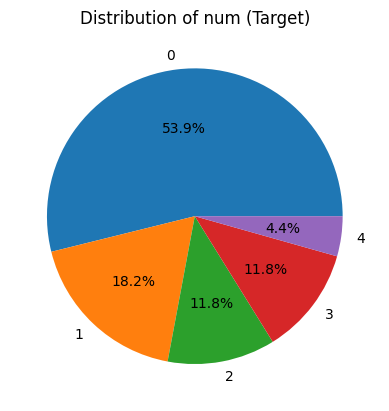

In [16]:
df_heart_no_na['num'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of num (Target)')
plt.ylabel('')
plt.show()

The data is **not balanced** – class 0 has significantly more observations than the other classes.

**Task 2.2**

Basic descriptive statistics for each numerical feature (min, max, mean, median, standard deviation, and the 25th, 50th, and 75th percentiles).

In [17]:
numerical_cols = df_heart_no_na.select_dtypes(include='number').columns.tolist()
numerical_cols

['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'num']

In [18]:
df_heart_no_na[numerical_cols].describe()

,age,trestbps,chol,thalach,oldpeak,ca,num
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,131.693603,247.350168,149.599327,1.055556,0.676768,0.946128
std,9.049736,17.762806,51.997583,22.941562,1.166123,0.938965,1.234551
min,29.000000,94.000000,126.000000,71.000000,0.000000,0.000000,0.000000
25%,48.000000,120.000000,211.000000,133.000000,0.000000,0.000000,0.000000
50%,56.000000,130.000000,243.000000,153.000000,0.800000,0.000000,0.000000
75%,61.000000,140.000000,276.000000,166.000000,1.600000,1.000000,2.000000
max,77.000000,200.000000,564.000000,202.000000,6.200000,3.000000,4.000000


**Task 2.3**

The mode for each categorical feature.

In [19]:
categorical_cols = df_heart_no_na.select_dtypes(include='category').columns.tolist()
categorical_cols

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

In [20]:
for col in categorical_cols:
    print(f"{col}: {df_heart_no_na[col].mode()[0]}")

sex: 1
cp: 4
fbs: 0
restecg: 0
exang: 0
slope: 1
thal: 3.0


**Task 2.4**

Display the Pearson correlation matrix for each numerical feature. Also display it on a heatmap using seaborn.

In [21]:
correlation_matrix = df_heart_no_na[numerical_cols].corr()
correlation_matrix

,age,trestbps,chol,thalach,oldpeak,ca,num
age,1.000000,0.290476,0.202644,-0.394563,0.197123,0.362210,0.222156
trestbps,0.290476,1.000000,0.131536,-0.049108,0.191243,0.097954,0.159620
chol,0.202644,0.131536,1.000000,-0.000075,0.038596,0.115945,0.066448
thalach,-0.394563,-0.049108,-0.000075,1.000000,-0.347640,-0.268727,-0.420639
oldpeak,0.197123,0.191243,0.038596,-0.347640,1.000000,0.294452,0.501461
ca,0.362210,0.097954,0.115945,-0.268727,0.294452,1.000000,0.521178
num,0.222156,0.159620,0.066448,-0.420639,0.501461,0.521178,1.000000


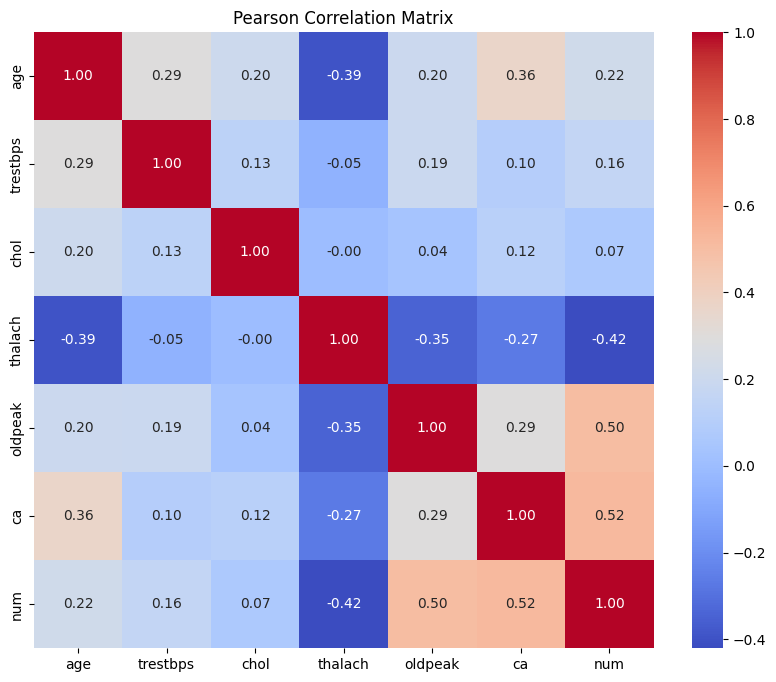

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pearson Correlation Matrix')
plt.show()

**Task 2.5**

From the correlation matrix, display the names of the three features most correlated with the `age` feature (absolute correlation values, excluding `age` itself).

In [23]:
age_corr = correlation_matrix['age'].drop('age').abs().sort_values(ascending=False)
age_corr.head(3)

thalach     0.394563
ca          0.362210
trestbps    0.290476
Name: age, dtype: float64

In [24]:
top_3 = age_corr.head(3).index.tolist()
print("Top 3 features most correlated with age:", top_3)

Top 3 features most correlated with age: ['thalach', 'ca', 'trestbps']


## Task 3

Use the Adult dataset. Set the categorical types for the appropriate columns.

In [25]:
adult = fetch_ucirepo(id=2)

X_adult = adult.data.features
y_adult = adult.data.targets

df_adult = pd.concat([X_adult, y_adult], axis=1)

In [26]:
df_adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [27]:
print(adult.variables)

              name     role         type      demographic  \
0              age  Feature      Integer              Age   
1        workclass  Feature  Categorical           Income   
2           fnlwgt  Feature      Integer              NaN   
3        education  Feature  Categorical  Education Level   
4    education-num  Feature      Integer  Education Level   
5   marital-status  Feature  Categorical            Other   
6       occupation  Feature  Categorical            Other   
7     relationship  Feature  Categorical            Other   
8             race  Feature  Categorical             Race   
9              sex  Feature       Binary              Sex   
10    capital-gain  Feature      Integer              NaN   
11    capital-loss  Feature      Integer              NaN   
12  hours-per-week  Feature      Integer              NaN   
13  native-country  Feature  Categorical            Other   
14          income   Target       Binary           Income   

                       

In [28]:
categorical_features_adult = adult.variables[adult.variables['type'] == 'Categorical']['name'].values.tolist()
categorical_features_adult

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'native-country']

In [29]:
for feature_name in categorical_features_adult:
    df_adult[feature_name] = df_adult[feature_name].astype('category')

In [30]:
df_adult.dtypes

age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex                    str
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
income                 str
dtype: object

In [31]:
df_adult = df_adult.dropna()
df_adult.shape

(47621, 15)

**Task 3.1**

Perform a t-test for paired samples on the `capital-gain` feature values. Null hypothesis: the mean value of `capital-gain` for `race`='White' is significantly higher than for the other `race` values.

In [32]:
white = df_adult[df_adult['race'] == 'White']['capital-gain']
not_white = df_adult[df_adult['race'] != 'White']['capital-gain']

In [33]:
print("Mean capital-gain for White:", white.mean())
print("Mean capital-gain for non-White:", not_white.mean())

Mean capital-gain for White: 1136.9898249399303
Mean capital-gain for non-White: 817.5272860277981


In [34]:
t_stat, p_value = stats.ttest_ind(white, not_white, alternative='greater')
print(f"t-statistic: {t_stat}")
print(f"p-value: {p_value}")

t-statistic: 3.264889335055905
p-value: 0.0005479206491372799


In [35]:
alpha = 0.05
if p_value < alpha:
    print("We reject the null hypothesis - the mean capital-gain for White is significantly higher than for other races.")
else:
    print("We fail to reject the null hypothesis - there is no significant difference.")

We reject the null hypothesis - the mean capital-gain for White is significantly higher than for other races.


**Task 3.2**

Using an ANOVA test, check how statistically significant the difference in the mean value of `capital-gain` is for each value of `race` separately. Report the p-values.

In [36]:
groups = [group['capital-gain'].values for name, group in df_adult.groupby('race')]

f_stat, p_value_anova = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat}")
print(f"p-value: {p_value_anova}")

F-statistic: 7.0454778510384966
p-value: 1.1499071279043072e-05


In [37]:
if p_value_anova < 0.05:
    print("The difference in mean capital-gain between race groups is statistically significant (p < 0.05).")
    print("This means that at least one race group has a significantly different mean capital-gain than the others.")
else:
    print("The difference is not statistically significant (p >= 0.05).")

The difference in mean capital-gain between race groups is statistically significant (p < 0.05).
This means that at least one race group has a significantly different mean capital-gain than the others.


## Task 4

Perform a chi-square test on the values of the `capital-gain` feature for two groups:
- people aged < 40
- people aged >= 40

In [38]:
df_adult['age_group'] = pd.cut(df_adult['age'], bins=[0, 39, 100], labels=['<40', '>=40'])

In [39]:
contingency_table = pd.crosstab(df_adult['age_group'], df_adult['capital-gain'])
contingency_table

capital-gain,0,114,401,594,914,991,1055,1086,1111,1151,...,15831,18481,20051,22040,25124,25236,27828,34095,41310,99999
age_group,,,,,,,,,,,,,,,,,,,,,
<40,25131,8,0,41,2,0,32,0,0,9,...,0,0,0,0,0,3,24,5,2,58
>=40,18526,0,3,7,8,6,3,8,1,4,...,8,2,48,1,6,11,34,1,1,182


In [40]:
chi2, p_value_chi, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value_chi}")
print(f"Degrees of freedom: {dof}")

Chi-square statistic: 1098.9110510963446


p-value: 2.630013218771308e-157
Degrees of freedom: 121


In [41]:
if p_value_chi < 0.05:
    print("The result is statistically significant - there is a relationship between age group and capital-gain.")
else:
    print("The result is not statistically significant - there is no relationship between age group and capital-gain.")

The result is statistically significant - there is a relationship between age group and capital-gain.
